# 04 — Event Study

Compute cumulative abnormal returns (CAR) in a [−48h, +72h] window around each DVOL signal event.

**Decision gate:** Peak post-event CAR > 0.3% net of transaction costs required to proceed to backtesting.

In [1]:
import sys
sys.path.append('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.event_study import build_event_windows, aggregate_car, peak_post_car
from pathlib import Path

cfg = yaml.safe_load(open('../config.yaml'))
es_cfg = cfg['event_study']
PRE = es_cfg['pre_window']
POST = es_cfg['post_window']
CAR_THRESHOLD = es_cfg['car_threshold']
COST = cfg['backtest']['commission'] + cfg['backtest']['slippage']

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
sig_dir = Path('../data/signals')
crypto_dir = Path('../data/crypto')

btc_sigs = pd.read_parquet(sig_dir / 'BTC_signals.parquet')
eth_sigs = pd.read_parquet(sig_dir / 'ETH_signals.parquet')

btc_ret = np.log(pd.read_parquet(crypto_dir / 'BTCUSDT_1h.parquet')['close']).diff()
eth_ret = np.log(pd.read_parquet(crypto_dir / 'ETHUSDT_1h.parquet')['close']).diff()

print(f'PRE={PRE}h, POST={POST}h, Cost threshold={CAR_THRESHOLD:.3f}')

PRE=48h, POST=72h, Cost threshold=0.003


## 1. BTC Event Study

In [3]:
def run_event_study(sigs: pd.DataFrame, ret: pd.Series,
                     definition: str, currency: str) -> dict:
    sig = sigs[definition]
    events = build_event_windows(sig, ret, pre=PRE, post=POST)
    car_df = aggregate_car(events)

    bull_n = len(events['bullish'])
    bear_n = len(events['bearish'])
    print(f'{currency} {definition}: {bull_n} bullish events, {bear_n} bearish events')

    return {'car': car_df, 'events': events, 'definition': definition, 'currency': currency}

results = {}
for sig_name in ['D1', 'D2', 'D3', 'D4']:
    for ccy, sigs, ret in [('BTC', btc_sigs, btc_ret), ('ETH', eth_sigs, eth_ret)]:
        key = f'{ccy}_{sig_name}'
        results[key] = run_event_study(sigs, ret, sig_name, ccy)

BTC D1: 352 bullish events, 206 bearish events
ETH D1: 334 bullish events, 193 bearish events
BTC D2: 80 bullish events, 31 bearish events
ETH D2: 74 bullish events, 15 bearish events
BTC D3: 494 bullish events, 403 bearish events
ETH D3: 492 bullish events, 412 bearish events
BTC D4: 347 bullish events, 207 bearish events
ETH D4: 332 bullish events, 188 bearish events


## 2. CAR Plots

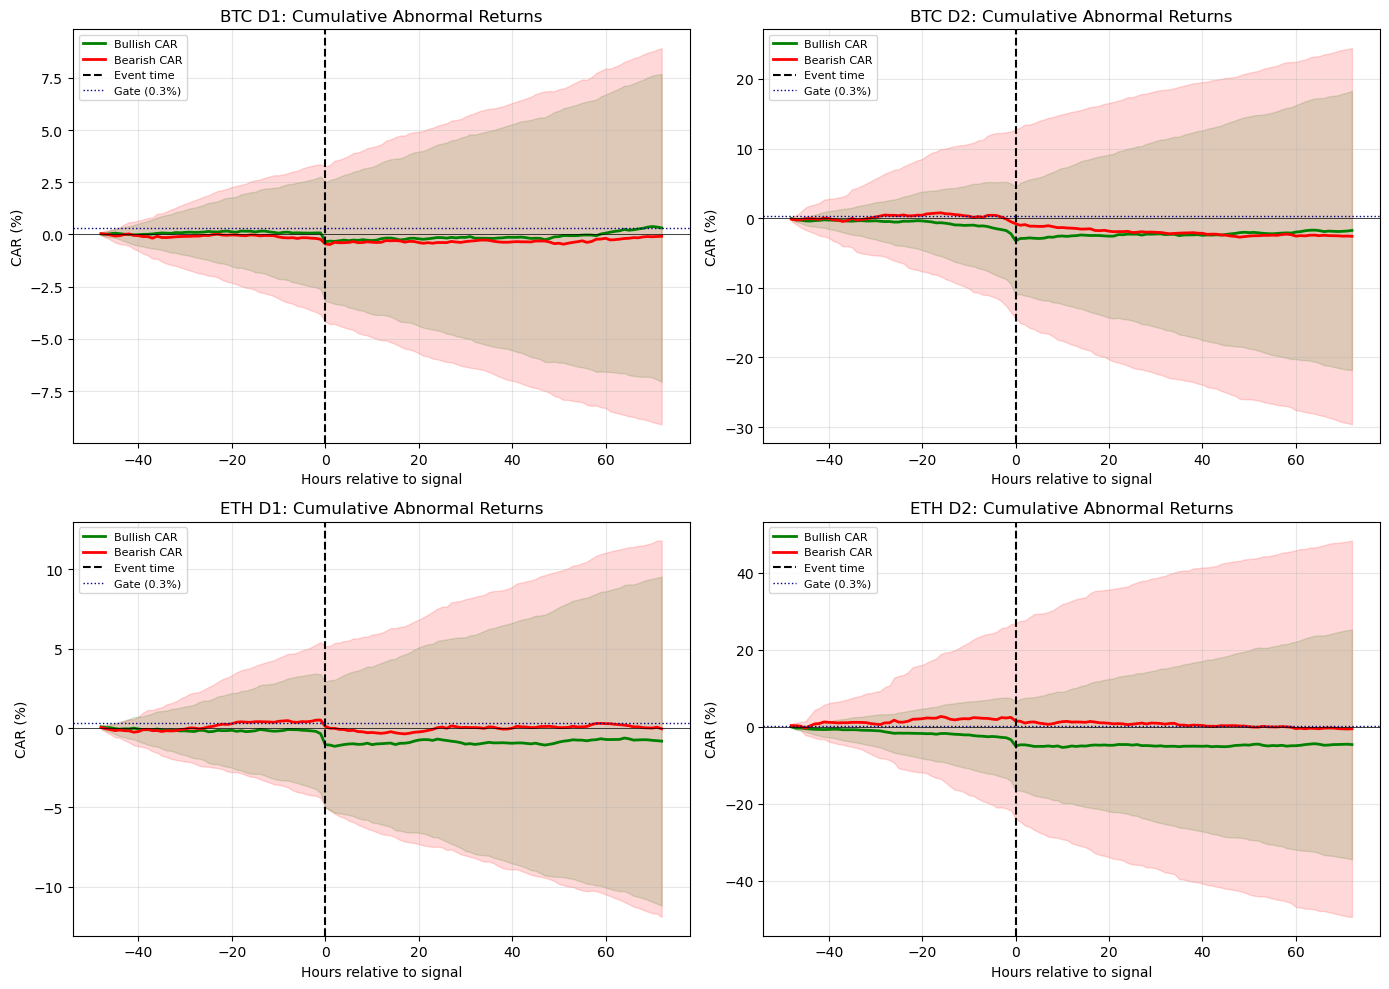

In [4]:
def plot_car(result: dict, ax=None):
    car_df = result['car']
    ccy = result['currency']
    definition = result['definition']

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    if 'bull_car' in car_df.columns:
        ax.plot(car_df.index, car_df['bull_car'] * 100, color='green', lw=2, label='Bullish CAR')
        ax.fill_between(car_df.index, car_df['bull_lower'] * 100,
                         car_df['bull_upper'] * 100, alpha=0.15, color='green')

    if 'bear_car' in car_df.columns:
        ax.plot(car_df.index, car_df['bear_car'] * 100, color='red', lw=2, label='Bearish CAR')
        ax.fill_between(car_df.index, car_df['bear_lower'] * 100,
                         car_df['bear_upper'] * 100, alpha=0.15, color='red')

    ax.axvline(0, color='black', lw=1.5, ls='--', label='Event time')
    ax.axhline(CAR_THRESHOLD * 100, color='navy', ls=':', lw=1, label=f'Gate ({CAR_THRESHOLD*100:.1f}%)')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('Hours relative to signal')
    ax.set_ylabel('CAR (%)')
    ax.set_title(f'{ccy} {definition}: Cumulative Abnormal Returns')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, key in enumerate(['BTC_D1', 'BTC_D2', 'ETH_D1', 'ETH_D2']):
    plot_car(results[key], ax=axes[i // 2][i % 2])

plt.tight_layout()
plt.savefig('../data/plots/car_main.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Decision Gate — Peak CAR Summary

In [5]:
print('='*60)
print('EVENT STUDY — DECISION GATE')
print(f'Threshold: peak CAR > {CAR_THRESHOLD*100:.1f}% net of costs')
print('='*60)

gate_passed = False
rows = []
for key, res in results.items():
    car_df = res['car']
    bull_peak = peak_post_car(car_df, 'bull_car')
    bear_peak = peak_post_car(car_df, 'bear_car')
    best_peak = max(bull_peak, bear_peak) if not (np.isnan(bull_peak) and np.isnan(bear_peak)) else float('nan')
    net = best_peak - COST if not np.isnan(best_peak) else float('nan')
    passed = (not np.isnan(net)) and net > CAR_THRESHOLD
    if passed:
        gate_passed = True
    rows.append({'definition': key, 'peak_bull_car': f'{bull_peak*100:.3f}%',
                 'peak_bear_car': f'{bear_peak*100:.3f}%',
                 'net_best': f'{net*100:.3f}%', 'gate': '✓' if passed else '✗'})

print(pd.DataFrame(rows).set_index('definition').to_string())
print()
print('→ PROCEED to Notebook 05 (Backtest)' if gate_passed else '→ No sufficient edge found. Revise thresholds.')

EVENT STUDY — DECISION GATE
Threshold: peak CAR > 0.3% net of costs
           peak_bull_car peak_bear_car net_best gate
definition                                          
BTC_D1            0.381%       -0.086%   0.281%    ✗
ETH_D1           -0.628%        0.297%   0.197%    ✗
BTC_D2           -1.717%       -0.799%  -0.899%    ✗
ETH_D2           -4.419%        1.467%   1.367%    ✓
BTC_D3            0.127%       -0.525%   0.027%    ✗
ETH_D3           -0.253%       -0.096%  -0.196%    ✗
BTC_D4            0.399%       -0.079%   0.299%    ✗
ETH_D4           -0.756%        0.160%   0.060%    ✗

→ PROCEED to Notebook 05 (Backtest)


## 4. Subgroup Analysis — By Market Regime

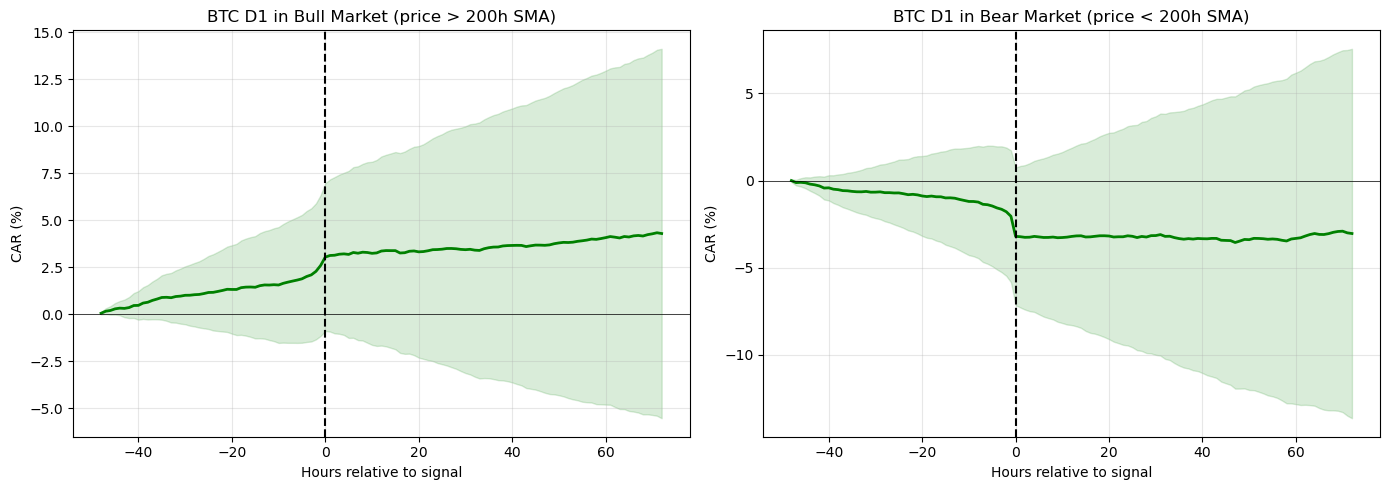

In [6]:
# Split events into bull/bear market regimes using 200h SMA of BTC price
btc_price = pd.read_parquet(crypto_dir / 'BTCUSDT_1h.parquet')['close']
sma200 = btc_price.rolling(200).mean()
bull_regime = (btc_price > sma200)

btc_d1 = btc_sigs['D1']
bull_sig = btc_d1[btc_d1.index.isin(bull_regime[bull_regime].index) & (btc_d1 != 0)]
bear_sig = btc_d1[btc_d1.index.isin(bull_regime[~bull_regime].index) & (btc_d1 != 0)]

# Reconstruct as full series for event study
btc_d1_bull = pd.Series(0, index=btc_d1.index, dtype=int)
btc_d1_bull[bull_sig.index] = bull_sig
btc_d1_bear = pd.Series(0, index=btc_d1.index, dtype=int)
btc_d1_bear[bear_sig.index] = bear_sig

bull_events = build_event_windows(btc_d1_bull, btc_ret, pre=PRE, post=POST)
bear_events = build_event_windows(btc_d1_bear, btc_ret, pre=PRE, post=POST)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, events, title in [
    (axes[0], bull_events, 'BTC D1 in Bull Market (price > 200h SMA)'),
    (axes[1], bear_events, 'BTC D1 in Bear Market (price < 200h SMA)')
]:
    car_df = aggregate_car(events)
    if 'bull_car' in car_df.columns:
        ax.plot(car_df.index, car_df['bull_car'] * 100, color='green', lw=2)
        ax.fill_between(car_df.index, car_df['bull_lower'] * 100,
                         car_df['bull_upper'] * 100, alpha=0.15, color='green')
    ax.axvline(0, color='black', lw=1.5, ls='--')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(title)
    ax.set_xlabel('Hours relative to signal')
    ax.set_ylabel('CAR (%)')

plt.tight_layout()
plt.savefig('../data/plots/car_regime.png', dpi=150, bbox_inches='tight')
plt.show()